In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
from PIL import Image
from tensorflow import keras
import seaborn as sns

In [18]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [19]:
X_train=X_train/255.0
X_test=X_test/255.0

In [20]:
X_train=X_train.reshape(-1,784)
X_test=X_test.reshape(-1,784)

In [21]:
y_train_oh = np.eye(10)[y_train]
y_test_oh  = np.eye(10)[y_test]

In [22]:
X_train, X_val, y_train_oh, y_val_oh = train_test_split(
    X_train, y_train_oh, test_size=0.2, random_state=42, stratify=y_train
)

In [23]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [24]:
model= keras.Sequential([
    layers.Dense(128,activation="relu",input_shape=(784,)),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
train = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9851 - loss: 0.0520 - val_accuracy: 0.9747 - val_loss: 0.1172
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9928 - loss: 0.0219 - val_accuracy: 0.9713 - val_loss: 0.1434
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9940 - loss: 0.0187 - val_accuracy: 0.9732 - val_loss: 0.1336
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9937 - loss: 0.0180 - val_accuracy: 0.9728 - val_loss: 0.1470
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9949 - loss: 0.0161 - val_accuracy: 0.9722 - val_loss: 0.1441
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9947 - loss: 0.0163 - val_accuracy: 0.9764 - val_loss: 0.1263
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9959 - loss: 0.0140 - val_accuracy: 0.9753 - val_loss: 0.1264
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9947 - loss: 0.0157 - 

In [36]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_oh, verbose=0)
print("Accuracy:",test_accuracy)
print("Loss:", test_loss)

Accuracy: 0.9722999930381775
Loss: 0.15380458533763885


In [37]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test_oh, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


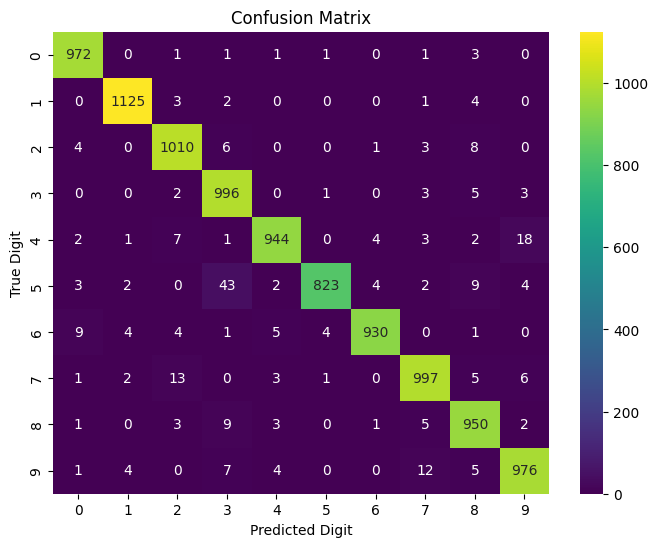

In [38]:
cm = tf.math.confusion_matrix(y_true, y_pred).numpy()
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.show()

In [30]:
sample = X_test[0].reshape(1, 784)
prediction = model.predict(sample)

predicted_class = np.argmax(prediction)
print("Predicted Digit:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Digit: 7


In [31]:
image_to_show = sample.reshape(28, 28)

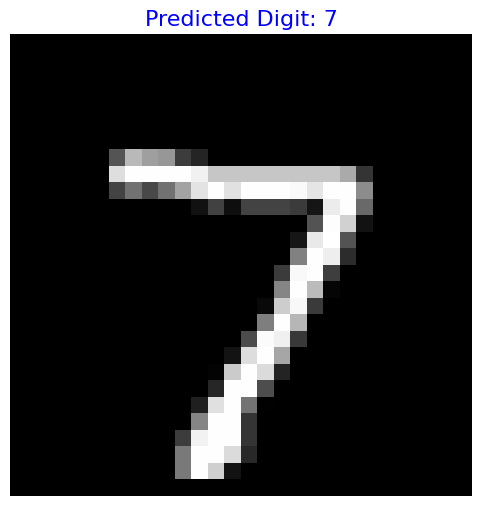

Predicted Digit: 7


In [32]:
plt.figure(figsize=(6, 6))
plt.imshow(image_to_show, cmap='gray')
plt.title(f"Predicted Digit: {predicted_class}",
          fontsize=16, color='blue')
plt.axis('off')
plt.show()

print(f"Predicted Digit: {predicted_class}")